### Density analysis across window sizes

Let's analyze how the distribution of different antisense transcription types changes across different window sizes

# Analysis transcription type
## Analysis of antisense transcription
### Author: Martin Loza
### Date: 26/01/18


In [6]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
})

# Local variables 
seed = 777
date = "260117"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
text_size = 18
width = 18.6
dot_size = 4
line_size = 1.5
dpi = 300

in_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Annotated_ncRNA_PCG_pairs/"
ensembl_raw_annotation_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/ENSEMBL/selected/"
out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/04_Figure_3/Plots/"

# Local Functions

# Simplified function to calculate density metrics for a given window size
calculate_density_metrics <- function(data, window_size, distance_column = "abs_strand_distance") {
    # Filter data within the window
    filtered_data <- data %>%
        filter(!!sym(distance_column) <= window_size)
    
    # Calculate counts and density
    metrics <- filtered_data %>%
        group_by(ncrna_strand) %>%
        summarise(count = n(), .groups = 'drop') %>%
        mutate(
            window_size = window_size,
            strand = ifelse(ncrna_strand == 1, "Forward", "Reverse"),
            density = count / window_size
        )
    
    return(metrics)
}

### Load and setup the data

In [7]:
# Load the setup transcripts data
# We have different species, so let's create a list to store the data
data_list = list()

# Search for the available files
files <- list.files(in_dir)

# Let's focus on human and mouse
files <- files[str_detect(files, "human|mouse")]

# Load the data for each species
for (file in files) {
    # Remove the underscore and everything after it to get the species names
    species_name <- str_replace(file, "_.*", "")
    data_list[[species_name]] <- read.table(file.path(in_dir, file), sep = "\t", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL)
}

head(data_list[["human"]], 3)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590333,BRSK1,55282072,749281,749281,NA,FALSE
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000346968,CACNG6,53992878,-539913,-539913,NA,FALSE


In [8]:
# Let's place an order in the plots
ordered_species <- c("human", "mouse")
# Arrange the data_list according to the ordered_species
data_selected_list <- data_list[ordered_species]

Let's focus only in lncRNAs related to TF genes 

In [9]:
# Select only observations related to lncRNA and TF genes
data_list_selected <- list()
for (species in names(data_list)) {
    data_list_selected[[species]] <- data_list[[species]] %>%
        filter(gene_biotype == "lncRNA") %>%
        filter(is_TF == TRUE)
}

In [10]:
head(data_list[["human"]], 3)
table(data_list[["human"]]$gene_biotype)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590333,BRSK1,55282072,749281,749281,NA,FALSE
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000346968,CACNG6,53992878,-539913,-539913,NA,FALSE



              lncRNA                miRNA             misc_RNA 
             4155667                59680                54615 
processed_transcript             ribozyme                 rRNA 
                 199                  289                  788 
     rRNA_pseudogene               scaRNA               snoRNA 
                9135                 1615                24419 
               snRNA                 sRNA 
               43525                  215 

Let's recover the strand annotation of pcg. Let's load the original information to map missing columns

In [11]:
# Load the raw-selected transcripts data
# We have different species, so let's create a list to store the data
data_list_raw = list()

# Search for the available files
files <- list.files(ensembl_raw_annotation_dir)

# Let's focus on human and mouse
files <- files[str_detect(files, "human|mouse")]

# Load the data for each species
for (file in files) {
    # Remove the underscore and everything after it to get the species names
    species_name <- str_replace(file, "_.*", "")
    data_list_raw[[species_name]] <- read.table(file.path(ensembl_raw_annotation_dir, file), sep = "\t", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL)
}

head(data_list_raw[["human"]], 3)

,row.names,Chromosome.scaffold.name,Gene.start..bp.,Gene.end..bp.,Strand,Gene.stable.ID,Transcript.stable.ID,Transcript.start..bp.,Transcript.end..bp.,Transcript.type,Gene.type,Gene.name,Gene.description,TSS,is_pcg,is_ncrna
,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>
1,1,1,11121,24894,1,ENSG00000290825,ENST00000456328,11850,14416,lncRNA,lncRNA,DDX11L16,DEAD/H-box helicase 11 like 16 (pseudogene) [Source:NCBI gene (formerly Entrezgene);Acc:727856],11850,FALSE,TRUE
2,2,1,11121,24894,1,ENSG00000290825,ENST00000832823,14404,24894,lncRNA,lncRNA,DDX11L16,DEAD/H-box helicase 11 like 16 (pseudogene) [Source:NCBI gene (formerly Entrezgene);Acc:727856],14404,FALSE,TRUE
3,3,1,11121,24894,1,ENSG00000290825,ENST00000832824,11121,14413,lncRNA,lncRNA,DDX11L16,DEAD/H-box helicase 11 like 16 (pseudogene) [Source:NCBI gene (formerly Entrezgene);Acc:727856],11121,FALSE,TRUE


Let's map the missing columns

In [12]:
colnames(data_list[["human"]])
colnames(data_list_raw[["human"]])

[1] "chromosome"      "ncRNA_id"        "ncrna_tss"       "ncrna_gene_name"
 [5] "ncrna_strand"    "gene_biotype"    "pcg_id"          "pcg_gene_name"  
 [9] "pcg_tss"         "dna_distance"    "strand_distance" "Family"         
[13] "is_TF"

[1] "row.names"                "Chromosome.scaffold.name"
 [3] "Gene.start..bp."          "Gene.end..bp."           
 [5] "Strand"                   "Gene.stable.ID"          
 [7] "Transcript.stable.ID"     "Transcript.start..bp."   
 [9] "Transcript.end..bp."      "Transcript.type"         
[11] "Gene.type"                "Gene.name"               
[13] "Gene.description"         "TSS"                     
[15] "is_pcg"                   "is_ncrna"

In [13]:
# We need to map start, end and strand information from the raw data to the selected data
sel_cols <- c('Transcript.stable.ID','Transcript.start..bp.','Transcript.end..bp.','Strand')
tmp_raw_list <- lapply(data_list_raw, function(df) df[, sel_cols])

# create a new list to store the annotated data
data_ann_list <- list()
for (species in names(data_list)) {
    # Map the lncRNA information
    data_ann_list[[species]] <- data_list[[species]] %>%
        left_join(
            tmp_raw_list[[species]],
            by = c("ncRNA_id" = "Transcript.stable.ID")
        ) %>%
        dplyr::rename(
            lncRNA_start = Transcript.start..bp.,
            lncRNA_end = Transcript.end..bp.,
            lncRNA_strand = Strand
        ) %>% # map the PCG information
        left_join(
            tmp_raw_list[[species]],
            by = c("pcg_id" = "Transcript.stable.ID") 
        ) %>%
        dplyr::rename(
            pcg_start = Transcript.start..bp.,
            pcg_end = Transcript.end..bp.,
            pcg_strand = Strand
        )
}

In [14]:
head(data_ann_list[["human"]] %>% filter(pcg_strand == -1), 3)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF,lncRNA_start,lncRNA_end,lncRNA_strand,pcg_start,pcg_end,pcg_strand
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>,<int>,<int>,<int>,<int>,<int>,<int>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE,54532791,54543732,1,55463001,55464751,-1
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000301200,CDC42EP5,54473296,-59495,-59495,NA,FALSE,54532791,54543732,1,54465026,54473296,-1
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590900,COX6B2,55354540,821749,821749,NA,FALSE,54532791,54543732,1,55350413,55354540,-1


In [15]:
# Function to annotate transcription relationships between lncRNA and PCG pairs
annotate_transcription_relation <- function(data) {
  # Ensure that the genomic gene bodies are expressed correctly  
  # (i.e., lncRNA_lower is the minimum of the lncRNA_start/end regardless of strand)  
  df <- data %>%  
    mutate(  
      lncRNA_lower = pmin(lncRNA_start, lncRNA_end),  
      lncRNA_upper = pmax(lncRNA_start, lncRNA_end),  
      pcg_lower    = pmin(pcg_start, pcg_end),  
      pcg_upper    = pmax(pcg_start, pcg_end)  
    )  
    
  # Step 1. Compute adjusted TSS and TTS based on strand.  
  # For positive strand (1): TSS = start and TTS = end.  
  # For negative strand (-1): TSS = end and TTS = start.  
  df <- df %>%  
    mutate(  
      adj_ncrna_TSS = if_else(lncRNA_strand == 1, lncRNA_start, lncRNA_end),  
      adj_ncrna_TTS = if_else(lncRNA_strand == 1, lncRNA_end,   lncRNA_start),  
      adj_pcg_TSS   = if_else(pcg_strand == 1, pcg_start,    pcg_end),  
      adj_pcg_TTS   = if_else(pcg_strand == 1, pcg_end,      pcg_start)  
    )  
    
  # Step 2. Compute the overlapping region (if any) between the two gene bodies.  
  df <- df %>%  
    mutate(  
      overlap_lower = pmax(lncRNA_lower, pcg_lower),  
      overlap_upper = pmin(lncRNA_upper, pcg_upper),  
      gene_overlap  = overlap_lower <= overlap_upper  # TRUE if gene bodies overlap  
    )  
    
  # Step 3. Classify the transcription relationship.  
  # (Note: These categories are most meaningful for transcripts on opposite strands.)  
  df <- df %>%  
    mutate(  
      transcription_relation = case_when(  
        # First, if the pair is on the same strand, we simply mark it "sense".  
        lncRNA_strand == pcg_strand ~ "sense",  
          
        # Fully overlapping: one gene body is completely contained within the other.  
        ((lncRNA_lower >= pcg_lower & lncRNA_upper <= pcg_upper) |  
         (pcg_lower >= lncRNA_lower & pcg_upper <= lncRNA_upper)) ~ "fully overlapping",  
          
        # Overlapping by 5'-terminus (head-to-head):  
        # They are on opposite strands, gene bodies overlap,  
        # and both adjusted TSS fall into the overlapping region.  
        gene_overlap &  
        (adj_ncrna_TSS >= overlap_lower & adj_ncrna_TSS <= overlap_upper) &  
        (adj_pcg_TSS   >= overlap_lower & adj_pcg_TSS   <= overlap_upper) ~ "overlapping head-to-head",  
          
        # Overlapping by 3'-terminus (tail-to-tail):  
        # They are on opposite strands, gene bodies overlap,  
        # and both adjusted TTS fall into the overlapping region.  
        gene_overlap &  
        (adj_ncrna_TTS >= overlap_lower & adj_ncrna_TTS <= overlap_upper) &  
        (adj_pcg_TTS   >= overlap_lower & adj_pcg_TTS   <= overlap_upper) ~ "overlapping tail-to-tail",  
          
        # Nearby 5'-terminus (nearby head-to-head):  
        # They are on opposite strands, gene bodies do NOT overlap,  
        # and the TSS are arranged in a head-to-head (divergent) orientation.  
        !gene_overlap &  
        (  
          ((lncRNA_strand == 1 & pcg_strand == -1) & (adj_ncrna_TSS < adj_pcg_TSS)) |  
          ((lncRNA_strand == -1 & pcg_strand == 1) & (adj_pcg_TSS < adj_ncrna_TSS))  
        ) ~ "nearby head-to-head",  
          
        # Nearby 3'-terminus (nearby tail-to-tail):  
        # They are on opposite strands, gene bodies do NOT overlap,  
        # and the TTS are arranged in a tail-to-tail (convergent) orientation.  
        !gene_overlap &  
        (  
          ((lncRNA_strand == 1 & pcg_strand == -1) & (adj_ncrna_TTS < adj_pcg_TTS)) |  
          ((lncRNA_strand == -1 & pcg_strand == 1) & (adj_pcg_TTS < adj_ncrna_TTS))  
        ) ~ "nearby tail-to-tail",  
          
        # If none of the above conditions are met, mark it as "other"  
        TRUE ~ "other"  
      )  
    )  
    
  return(df)
}

In [16]:
# Apply annotation function to both species
for (species in names(data_ann_list)) {
    data_ann_list[[species]] <- annotate_transcription_relation(data_ann_list[[species]])
}

# Check the distribution of transcription relations for human
table(data_ann_list[["human"]]$transcription_relation) %>% sort(decreasing = TRUE)


                   sense                    other      nearby head-to-head 
                 2111056                  1176139                  1004016 
       fully overlapping overlapping head-to-head overlapping tail-to-tail 
                   30844                    17092                    11000 

### Focus on antisense transcription only

Let's filter to keep only antisense pairs (excluding "sense" pairs since we already compared sense vs antisense)

In [17]:
# Filter to keep only antisense pairs (exclude "sense")
data_antisense_list <- list()

for (species in names(data_ann_list)) {
    data_antisense_list[[species]] <- data_ann_list[[species]] %>%
        filter(transcription_relation != "sense")
}

# Check the distribution for each species
for (species in names(data_antisense_list)) {
    cat("\n", str_to_title(species), ":\n", sep="")
    print(table(data_antisense_list[[species]]$transcription_relation) %>% sort(decreasing = TRUE))
}


Human:

                   other      nearby head-to-head        fully overlapping 
                 1176139                  1004016                    30844 
overlapping head-to-head overlapping tail-to-tail 
                   17092                    11000 

Mouse:

                   other      nearby head-to-head        fully overlapping 
                  882010                   794888                    12769 
overlapping head-to-head overlapping tail-to-tail 
                   11541                     5649 


### Density analysis across window sizes

Let's analyze how the distribution of different antisense transcription types changes across different window sizes

In [18]:
# Define the window sizes to compare (in bp)
window_sizes <- c(1000, 5000, 10000, 50000, 100000, 500000, 1000000)

# Add absolute distance column if not already present
for (species in names(data_antisense_list)) {
    if (!"abs_dna_distance" %in% colnames(data_antisense_list[[species]])) {
        data_antisense_list[[species]] <- data_antisense_list[[species]] %>%
            mutate(abs_dna_distance = abs(dna_distance))
    }
}

In [19]:
# Separate data by antisense transcription type for each species
data_by_type_list <- list()

for (species in names(data_antisense_list)) {
    antisense_types <- unique(data_antisense_list[[species]]$transcription_relation)
    
    for (type in antisense_types) {
        key <- paste(species, type, sep = "_")
        data_by_type_list[[key]] <- data_antisense_list[[species]] %>%
            filter(transcription_relation == type)
    }
}

# Calculate density metrics for all antisense types
all_density_antisense <- list()

for (key in names(data_by_type_list)) {
    type_metrics <- data.frame()
    
    # Extract species and type from key
    parts <- strsplit(key, "_")[[1]]
    species <- parts[1]
    type <- paste(parts[-1], collapse = " ")
    
    for (ws in window_sizes) {
        # Count pairs within window
        count_in_window <- data_by_type_list[[key]] %>%
            filter(abs_dna_distance <= ws) %>%
            nrow()
        
        # Calculate density
        density <- count_in_window / ws
        
        type_metrics <- rbind(type_metrics, data.frame(
            window_size = ws,
            count = count_in_window,
            density = density,
            species = species,
            transcription_relation = type
        ))
    }
    
    all_density_antisense[[key]] <- type_metrics
}

# Combine all metrics
density_antisense_df <- do.call(rbind, all_density_antisense)
rownames(density_antisense_df) <- NULL

head(density_antisense_df, 15)

,window_size,count,density,species,transcription_relation
,<dbl>,<int>,<dbl>,<chr>,<chr>
1,1e+03,1,0.001000,human,nearby head-to-head
2,5e+03,384,0.076800,human,nearby head-to-head
3,1e+04,2400,0.240000,human,nearby head-to-head
4,5e+04,31766,0.635320,human,nearby head-to-head
5,1e+05,81717,0.817170,human,nearby head-to-head
6,5e+05,511323,1.022646,human,nearby head-to-head
7,1e+06,1004016,1.004016,human,nearby head-to-head
8,1e+03,45931,45.931000,human,other
9,5e+03,55702,11.140400,human,other


### Statistical testing

Perform pairwise chi-square tests comparing each antisense type at each window size

In [21]:
# Statistical testing: Compare main antisense categories
# Focus on the most abundant categories for comparison

# Get the top antisense categories for each species
for (species in c("human", "mouse")) {
    cat("\n", str_to_title(species), " antisense categories:\n", sep="")
    print(table(data_antisense_list[[species]]$transcription_relation) %>% sort(decreasing = TRUE))
}

# Let's focus on comparing the most biologically meaningful categories:
# 1. "nearby head-to-head" (divergent transcription)
# 2. "overlapping head-to-head" 
# 3. Other antisense types combined

# For each species, perform pairwise comparisons
pvalue_antisense_results <- list()

for (sp in c("human", "mouse")) {
    # Get the antisense types for this species
    antisense_types <- unique(data_antisense_list[[sp]]$transcription_relation)
    
    # For each pair of antisense types
    for (i in 1:(length(antisense_types)-1)) {
        for (j in (i+1):length(antisense_types)) {
            type1 <- antisense_types[i]
            type2 <- antisense_types[j]
            
            type1_key <- paste(sp, type1, sep = "_")
            type2_key <- paste(sp, type2, sep = "_")
            
            for (ws in window_sizes) {
                # Get data for both types
                type1_data <- data_by_type_list[[type1_key]] %>% 
                    filter(abs_dna_distance <= ws)
                type2_data <- data_by_type_list[[type2_key]] %>% 
                    filter(abs_dna_distance <= ws)
                
                # Get counts
                type1_count <- nrow(type1_data)
                type2_count <- nrow(type2_data)
                
                # Get total counts
                total_type1 <- nrow(data_by_type_list[[type1_key]])
                total_type2 <- nrow(data_by_type_list[[type2_key]])
                
                # Skip if either total is 0
                if (total_type1 == 0 | total_type2 == 0) next
                
                # Create contingency table
                cont_table <- matrix(c(type1_count, total_type1 - type1_count,
                                       type2_count, total_type2 - type2_count),
                                     nrow = 2, byrow = FALSE)
                
                # Skip if any cell has 0 (can't do chi-square)
                if (any(cont_table == 0)) next
                
                test_result <- chisq.test(cont_table)
                
                pvalue_antisense_results[[length(pvalue_antisense_results) + 1]] <- data.frame(
                    species = sp,
                    window_size = ws,
                    type1 = type1,
                    type2 = type2,
                    pvalue = test_result$p.value,
                    type1_count = type1_count,
                    type2_count = type2_count,
                    type1_density = type1_count / ws,
                    type2_density = type2_count / ws
                )
            }
        }
    }
}

pvalue_antisense_df <- do.call(rbind, pvalue_antisense_results)

# Apply FDR correction
pvalue_antisense_df <- pvalue_antisense_df %>%
    mutate(
        fdr = p.adjust(pvalue, method = "fdr"),
        significance = case_when(
            fdr < 0.001 ~ "***",
            fdr < 0.01 ~ "**",
            fdr < 0.05 ~ "*",
            TRUE ~ ""
        )
    )

print(pvalue_antisense_df)


Human antisense categories:

                   other      nearby head-to-head        fully overlapping 
                 1176139                  1004016                    30844 
overlapping head-to-head overlapping tail-to-tail 
                   17092                    11000 

Mouse antisense categories:

                   other      nearby head-to-head        fully overlapping 
                  882010                   794888                    12769 
overlapping head-to-head overlapping tail-to-tail 
                   11541                     5649 


Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”


    species window_size                    type1                    type2
1     human       1e+03      nearby head-to-head                    other
2     human       5e+03      nearby head-to-head                    other
3     human       1e+04      nearby head-to-head                    other
4     human       5e+04      nearby head-to-head                    other
5     human       1e+05      nearby head-to-head                    other
6     human       5e+05      nearby head-to-head                    other
7     human       1e+03      nearby head-to-head overlapping head-to-head
8     human       5e+03      nearby head-to-head overlapping head-to-head
9     human       1e+04      nearby head-to-head overlapping head-to-head
10    human       5e+04      nearby head-to-head overlapping head-to-head
11    human       1e+05      nearby head-to-head overlapping head-to-head
12    human       1e+03      nearby head-to-head        fully overlapping
13    human       5e+03      nearby he

### Visualization

Create density plots comparing different antisense transcription types

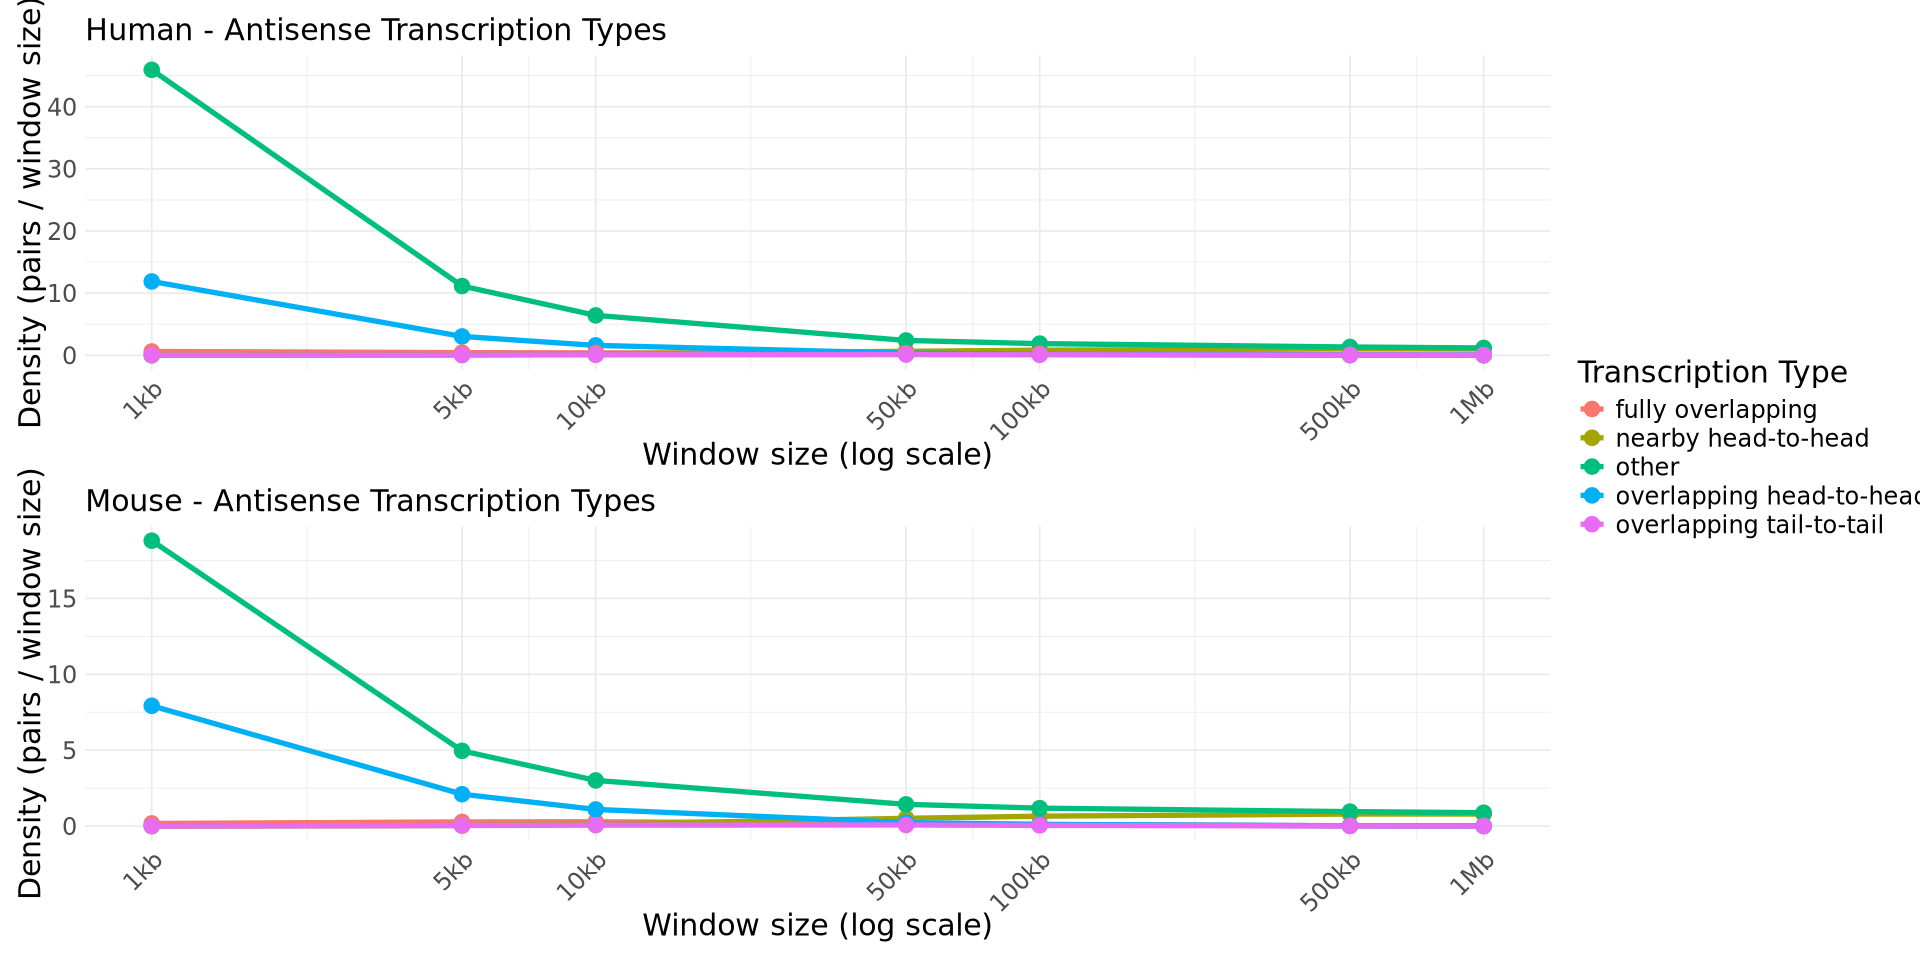

In [22]:
# Visualize antisense transcription types across window sizes
options(repr.plot.width=16, repr.plot.height=8)

# Create separate plots for each species
p_antisense_human <- density_antisense_df %>%
    filter(species == "human") %>%
    ggplot(aes(x = window_size / 1000, y = density, 
               color = transcription_relation, group = transcription_relation)) +
    geom_line(linewidth = line_size) +
    geom_point(size = dot_size) +
    scale_x_log10(breaks = window_sizes / 1000, 
                  labels = c("1kb", "5kb", "10kb", "50kb", "100kb", "500kb", "1Mb")) +
    theme_minimal() +
    labs(title = "Human - Antisense Transcription Types",
         x = "Window size (log scale)",
         y = "Density (pairs / window size)",
         color = "Transcription Type") +
    theme(text = element_text(size = text_size),
          plot.title = element_text(size = text_size),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "right")

p_antisense_mouse <- density_antisense_df %>%
    filter(species == "mouse") %>%
    ggplot(aes(x = window_size / 1000, y = density, 
               color = transcription_relation, group = transcription_relation)) +
    geom_line(linewidth = line_size) +
    geom_point(size = dot_size) +
    scale_x_log10(breaks = window_sizes / 1000, 
                  labels = c("1kb", "5kb", "10kb", "50kb", "100kb", "500kb", "1Mb")) +
    theme_minimal() +
    labs(title = "Mouse - Antisense Transcription Types",
         x = "Window size (log scale)",
         y = "Density (pairs / window size)",
         color = "Transcription Type") +
    theme(text = element_text(size = text_size),
          plot.title = element_text(size = text_size),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "right")

# Combine plots
p_antisense_combined <- p_antisense_human / p_antisense_mouse +
    plot_layout(guides = 'collect') & 
    theme(legend.position = 'right')

p_antisense_combined

In [ ]:
# Optional: Save the combined figure
# ggsave(filename = file.path(out_dir, paste0("Density_antisense_types_comparison_", date, ".pdf")),
#     plot = p_antisense_combined, 
#     width = width * 0.8, height = 10.0, units = "in", dpi = dpi)